## 0. Import and Definitions

In [ ]:
import os
import copy
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc
from sklearn.decomposition import PCA

from src.model.config import VAEConfig
from src.model.build_model import get_model

from src.model.data_utils import (
    prepare_train_test_data,
    load_data,
    build_metacells,
    prepare_data,
)
from src.model.Mean.Mean_model import MeanShifter

from src.analysis.mmd import gaussian_kernel, mmd, ctrl_mmd_dists, mmd_dists, plot_mmd_dists

from src.analysis.logistic_regression import (
    init_classifier, 
    train_classifier, 
    evaluate_cfs_classification, 
    evaluate_training_error, 
    generate_counterfactuals,
    generate_counterfactuals_mean,
)

from src.analysis.analysis_utils import Analyzer
from src.analysis.cf_expressions import plot_mean_expression_comparison, plot_top_deg_violin, plot_effect_size_comparison

## 1. Load Data

In [2]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

USE_METACELLS = False
DONOR = ["Donor1"]

if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=["CD4 Memory"],
    )
else:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=None,
        donors=DONOR,
    )
    print(adata.X.shape)
    adata = build_metacells(adata, group_keys=["cell_type", f"{labels_key}"])

dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])

## 2. Model

In [4]:
plot_dir = f"/home/jhoefer/sandbox/results/mean/plots/"
csv_dir = f"/home/jhoefer/sandbox/results/mean/csv/"
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

MeanShifter.setup_anndata(adata, labels_key, control_label)
mean_shifter = MeanShifter(adata)
mean_shifter.train()

## 3. Evaluation

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
conditions = [f"{labels_key}"]

dataset, train_dataloader, test_dataset, test_dataloader = prepare_train_test_data(
    adata,
    dataset_args["batch_size"],
    device,
    dtype,
    label_key=conditions,
    test_size=0.1,
)

D_dim = dataset.X.shape[1]
N_dim = D_dim

kwargs_data = {
    "device": device,
    "dtype": dtype,
    "N_dim": N_dim,
    "D_dim": D_dim,
    "dataset": dataset,
    "train_dataloader": train_dataloader,
    "test_dataloader": test_dataloader,
    "data_mean": dataset.X.mean(dim=0),
    "data_std": torch.ones(D_dim),
    "sigma_noise": 0.0,
    "sigma_inflate": 0.0,
}

analyzer = Analyzer(
    adata,
    mean_shifter,
    kwargs_data,
    labels_key,
    control_label,
    plot_dir,
    csv_dir,
    checkpoint_path=None,
)

In [6]:
key = "IL-2"

### 3.1 Counterfactuals

In [7]:
x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals_mean(analyzer, key=key)

adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
adata_real.obs["origin"] = "original"

adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
adata_cf.X = x_cfs.numpy()
adata_cf.obs["origin"] = "cfs"
adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

adata_combined = ad.concat([adata_real, adata_cf])

analyzer_cfs = copy.deepcopy(analyzer)
analyzer_cfs.adata = adata_combined

num_original = adata_real.shape[0]
num_cfs = adata_cf.shape[0]

weights = torch.tensor(
    [1.0 / num_cfs, 1.0 / num_original],
    dtype=torch.float32,
    device=device,
)

weights = weights / weights.sum() * len(weights)

In [8]:
cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, cfs_train_dataset, cfs_adata_train, cfs_num_classes = init_classifier(analyzer_cfs, key=key, latent=False, hidden_dim = None, labels_key="origin")

cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, weights, analyzer_cfs.device, num_epochs=10
)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:08<00:00,  1.19it/s]

Best Validation Accuracy: 0.6146


In [9]:
evaluate_training_error(analyzer, cfs_adata_train, "origin", cfs_num_classes, cfs_class_accuracies)
cats = cfs_train_dataset.cats[0].categories.tolist()
target_idx = cats.index("original")

,Class,Accuracy
0,cfs,0.651781
1,original,0.125232


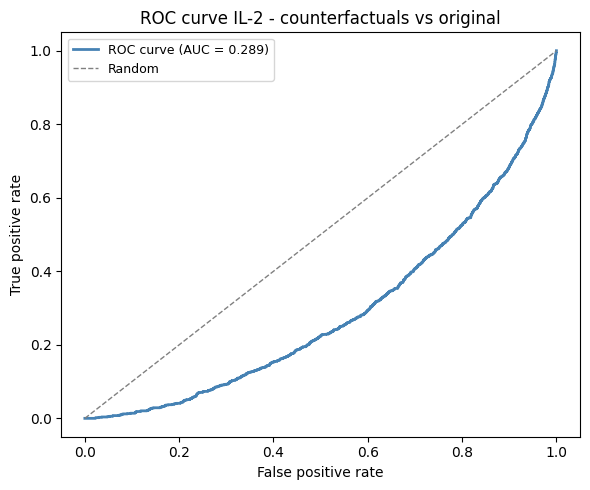

AUC: 0.289


In [10]:
cfs_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in cfs_test_dataloader:
        x = x.to(analyzer.device)
        logits = cfs_classifier(x)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# for binary classifier: use probability of positive class
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve {key} - counterfactuals vs original")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
plt.show()

print(f"AUC: {roc_auc:.3f}")

### 3.2 MMD

In [ ]:
ctrl_mmd = ctrl_mmd_dists(analyzer, key=key)
print(f"Control MMD (random split): {ctrl_mmd:.4f}")
global_mmd, mmd_per_group = mmd_dists(analyzer, key=key, sigma=1.0, cf_fn=generate_counterfactuals_mean)
print(f"Global MMD for {key}: {global_mmd}")

Control MMD (random split): 0.0003


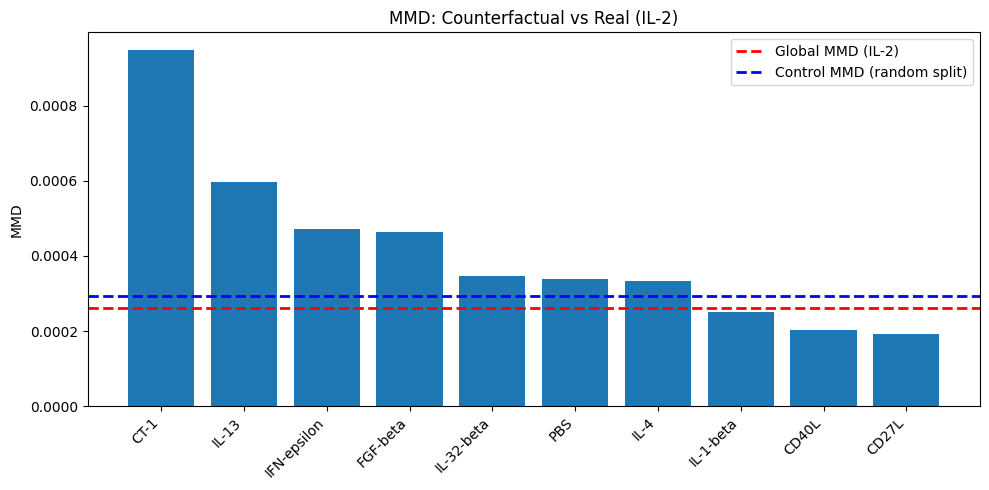

In [ ]:
plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key)

### 3.3 Mean Expressions

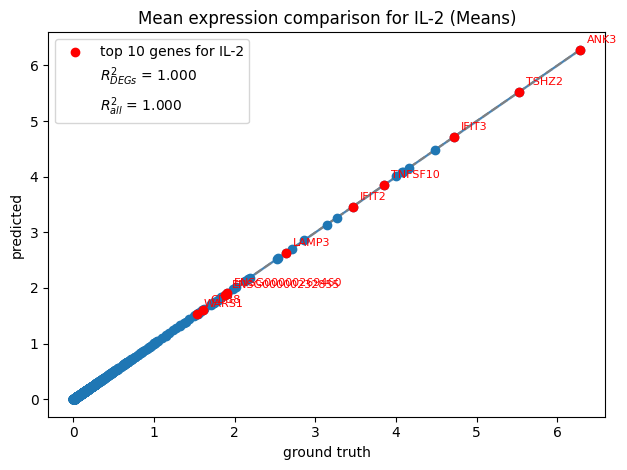

In [ ]:
plot_mean_expression_comparison(analyzer, key=key, top_n=10, method="Means", cfs_fn=generate_counterfactuals_mean)

In [ ]:
plot_effect_size_comparison(analyzer, key=key, top_n=10, method="Means", cfs_fn=generate_counterfactuals_mean)

### 3.4 Violin Plots

In [ ]:
from src.analysis.logistic_regression import generate_counterfactuals
from src.utils.utils import extract_top_genes, normalize_log1p
import pandas as pd

def plot_top_deg_violin(
    analyzer, key, cfs_fn=generate_counterfactuals, log1p_transform=False, gene_idx=0
):
    top_gene_names, gene_indices = extract_top_genes(
        analyzer, key, top_n=20, log1p_transform=log1p_transform
    )
    gene_name = top_gene_names[gene_idx]
    gene_idx = gene_indices[gene_idx]

    def gene_values(adata_subset):
        x = adata_subset.X.toarray() if hasattr(adata_subset.X, "toarray") else adata_subset.X
        if log1p_transform:
            x = normalize_log1p(x)
        return x[:, gene_idx]

    control_values = gene_values(
        analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == analyzer.control_label]
    )
    key_values = gene_values(analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key])

    x_cfs, z_cfs, all_source_labels, _ = cfs_fn(analyzer, key=key)
    # counterfactual = control cells predicted forward to `key`, matching the classic
    # ctrl -> stim comparison (rather than pooling counterfactuals from every source)
    cf_mask = np.asarray(all_source_labels) == analyzer.control_label
    cf_values = (
        x_cfs[cf_mask, gene_idx]
        .cpu()
        .numpy()
    )

    cf_label = f"{key} (counterfactual)"
    order = [analyzer.control_label, cf_label, key]

    values = np.concatenate([control_values, cf_values, key_values]).astype(np.float32)
    groups = (
        [analyzer.control_label] * len(control_values)
        + [cf_label] * len(cf_values)
        + [key] * len(key_values)
    )

    violin_adata = ad.AnnData(
        X=values.reshape(-1, 1),
        var=pd.DataFrame(index=[str(gene_name)]),
        obs=pd.DataFrame({"group": pd.Categorical(groups, categories=order)}),
    )

    ax = sc.pl.violin(
        violin_adata,
        keys=str(gene_name),
        groupby="group",
        order=order,
        use_raw=False,
        xlabel="",
        ylabel="expression",
        show=False,
    )
    ax.set_title(f"Top DEG for {key}: {gene_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(analyzer.plot_dir, f"top_deg_violin_{key}.png"), dpi=300)
    plt.show()


3.84124 4.7232027 4.7231855
5987 5987 597
20558 20558 4673


/scratch/jobs/59549957/ipykernel_478947/3307873078.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


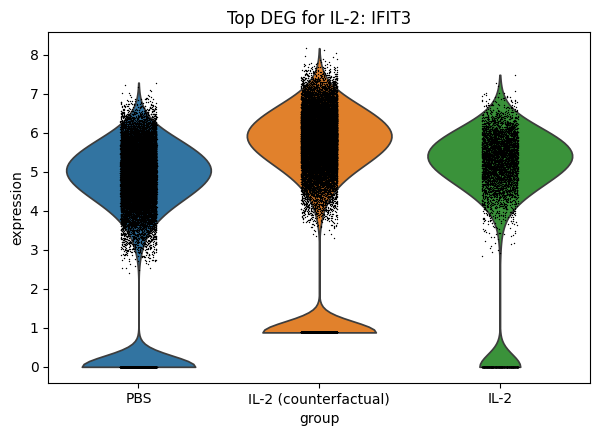

In [ ]:
plot_top_deg_violin(analyzer, key=key, cfs_fn=generate_counterfactuals_mean)